In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Load the Student Performance dataset

df = pd.read_csv("student_habits_performance.csv")

# Display the first 5 rows
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
# Display the number of rows and columns

print("Dataset Shape:", df.shape)

# Display information about columns and data types
df.info()

Dataset Shape: (1000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality       

In [5]:
# Check for missing values in each column

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [6]:
# Select all numeric columns

numeric_columns = df.select_dtypes(include=np.number).columns

print("Numeric Columns:")
print(numeric_columns)

Numeric Columns:
Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')


In [7]:
# Target column
target = "exam_score"

# Select numeric features
# exam_score is removed because it is our target variable

X = df[numeric_columns].drop(columns=[target])

# Target variable
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Features:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

Target:
exam_score


In [8]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 8)
Testing data: (200, 8)


In [9]:
# Create the Linear Regression model

model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


In [10]:
# Predict Exam Scores using the test data

y_pred = model.predict(X_test)

# Display first 10 predictions

print("Predicted Exam Scores:")
print(y_pred[:10])

Predicted Exam Scores:
[66.05204297 74.48132707 78.10484796 74.38034364 61.42454555 54.83488838
 75.91771188 55.42801281 41.61008609 72.81612496]


In [15]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Model Evaluation Results
------------------------
MAE  : 4.1302
MSE  : 25.9210
RMSE : 5.0913
R²   : 0.8989


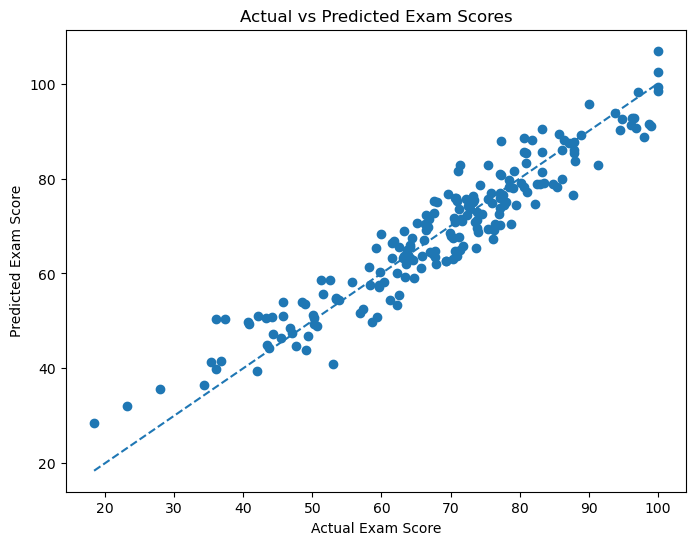

In [11]:
# Plot actual vs predicted exam scores

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [12]:
# Display the contribution/coefficient of each feature

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,study_hours_per_day,9.533589
5,sleep_hours,1.989896
7,mental_health_rating,1.952032
6,exercise_frequency,1.315593
4,attendance_percentage,0.145895
0,age,0.052559
3,netflix_hours,-2.316592
2,social_media_hours,-2.701878


In [16]:
# Display final model performance

print("Linear Regression Model Summary")
print("--------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

print("\nThe Linear Regression model was successfully trained")
print("to predict students' Exam Scores using numeric student")
print("habit and performance-related features.")

Linear Regression Model Summary
--------------------------------
Mean Absolute Error (MAE): 4.13
Mean Squared Error (MSE): 25.92
Root Mean Squared Error (RMSE): 5.09
R² Score: 0.90

The Linear Regression model was successfully trained
to predict students' Exam Scores using numeric student
habit and performance-related features.
